In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [30]:
df=pd.read_csv('../data/raw/ecommerce_inventory_demand.csv')

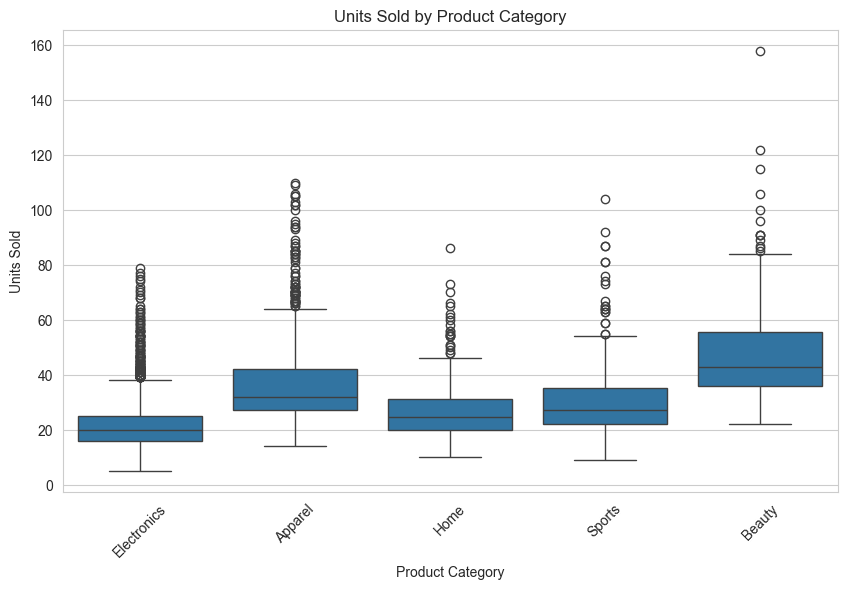

In [32]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="product_category", y="units_sold")
plt.title("Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

In [33]:
monthly_sales = df.groupby(['month', 'product_category'])['units_sold'].mean()

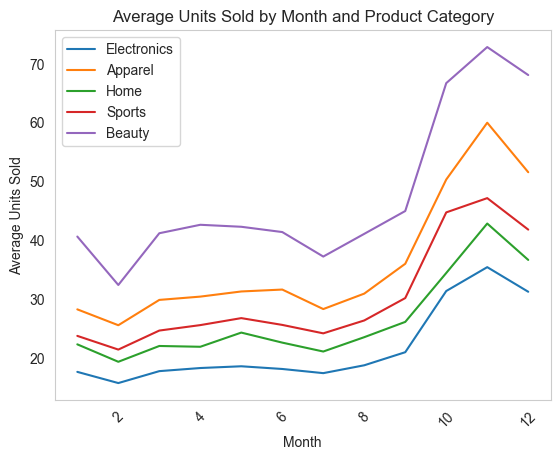

In [34]:
for category in df['product_category'].unique():
    category_sales = monthly_sales[monthly_sales.index.get_level_values('product_category') == category]
    plt.plot(category_sales.index.get_level_values('month'), category_sales.values, label=category)
plt.title("Average Units Sold by Month and Product Category")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

In [39]:
p035_sales = df[df['product_id'] == 'P035'][['units_sold']].dropna()

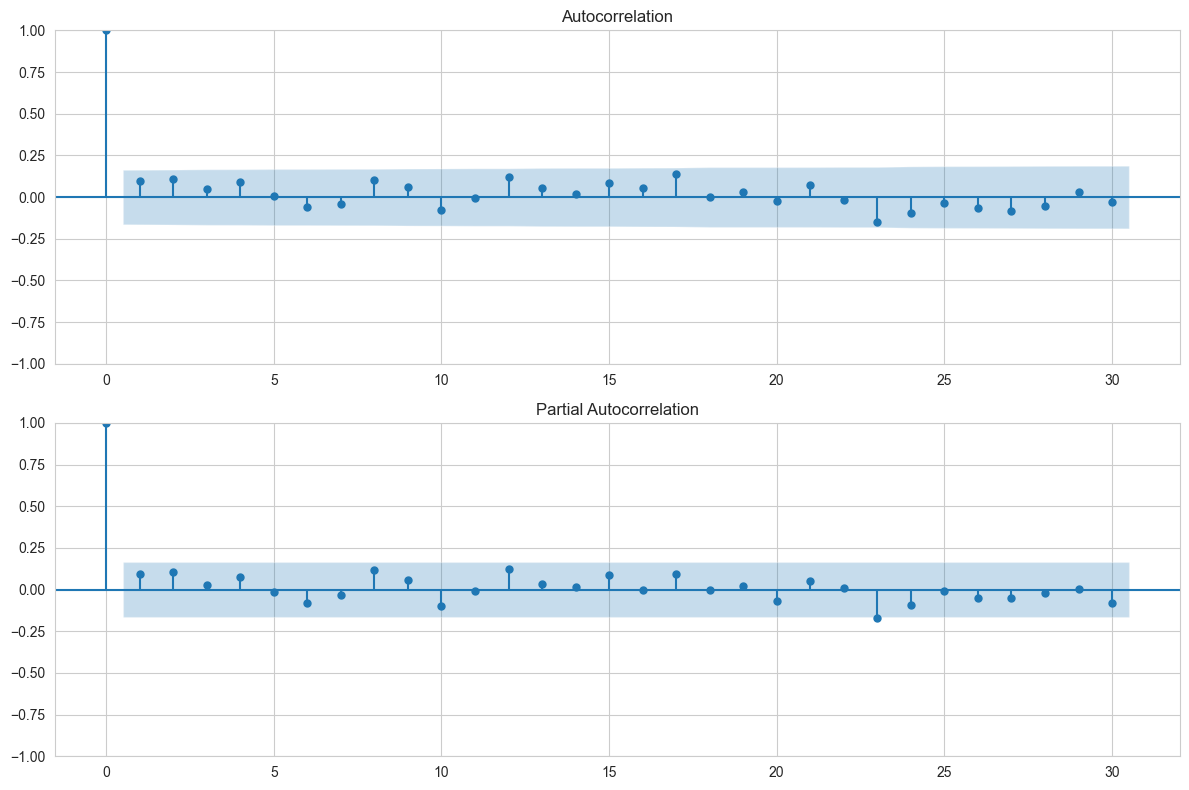

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(p035_sales, lags=30, ax=axes[0])
plot_pacf(p035_sales, lags=30, ax=axes[1])
plt.tight_layout()
plt.show()

In [42]:
df.groupby('is_promotion')['units_sold'].mean()

is_promotion
0    26.832119
1    53.510145
Name: units_sold, dtype: float64

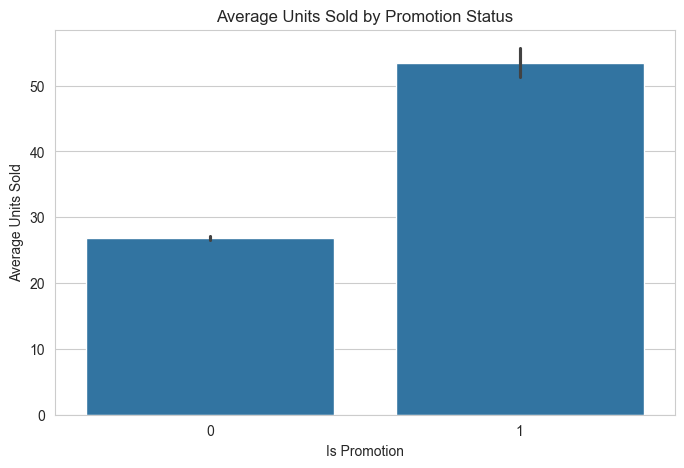

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='is_promotion', y='units_sold')
plt.title("Average Units Sold by Promotion Status")
plt.xlabel("Is Promotion")
plt.ylabel("Average Units Sold")
plt.show()
